# Open orders and suppliers: one café chain, two ways to buy coffee

A small café chain sells three coffees: a **house blend**, an **espresso** roast and a **decaf**. Every morning, before the doors open, the buyer checks the beans on the shelf and on order, and may order more. Two companies can supply the beans:

- a **local roaster**: delivers the next morning, but charges more per kilogram;
- an **importer**: cheaper, but ships from far away. Its lead time varies, and large orders arrive in two parts.

So far, every Stockcast example tracked stock on order as one number per future day and SKU (`in_transit`), with one fixed lead time. That per-SKU view is still the default and still what the accounting uses. This notebook adds the **order-level** view: individual open orders, each with its supplier, order day, due day and remaining quantity. With it we can simulate several suppliers, random lead times, deliveries that overtake each other, and partial deliveries.

We add one idea at a time:

1. the familiar per-SKU run with one supplier;
2. the *same* run, read order by order;
3. the *same* run, written with the new API (results are identical);
4. one day placed by hand, with two suppliers;
5. the importer with a fixed lead time;
6. the importer's random lead times and a planning choice;
7. dual sourcing, partial deliveries and a custom allocation rule;
8. a comparison of all the options.

Demand rates, prices and every operating assumption are declared below. This is a teaching example with artificial data, not evidence about any real café or supplier.

## 0. Setup: demand, prices and a target helper

We simulate 10 weeks of daily demand in kilograms. The first week is warm-up (the system settles from its opening stock), the next eight weeks are scored, and the last week is a settlement tail with no new orders. Cafés cannot backorder coffee: a customer who cannot get a house blend buys something else, so unmet demand is a **lost sale** (`allow_backorders=False`).

In [2]:
import math

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stockcast.core import (
    InventoryStateDataFrame, OrderLines, SimulationEngine,
    Supplier, SupplierAllocation, SupplierShares, SupplyModel,
)
from stockcast.evaluation import avg_on_hand, fill_rate, validate_event_frame
from stockcast.policies import OrderUpToPolicy
from stockcast.utils import place_order_lines

origin = pd.Timestamp("2026-04-05")  # Sunday evening stock count; demand starts Monday
skus = ["house_blend", "espresso", "decaf"]
rate = {"house_blend": 6.0, "espresso": 4.0, "decaf": 1.0}      # mean kg per day
opening_stock = {"house_blend": 14.0, "espresso": 9.0, "decaf": 3.0}
price = {"roaster": 14.0, "importer": 9.5}                        # purchase price, EUR per kg
holding_cost = 0.04                                               # EUR per kg on the shelf per day
alpha = 0.95                                                      # declared target probability
warmup, scoring, settlement = 7, 56, 7
n_periods = warmup + scoring + settlement

rng = np.random.default_rng(2026)
y = np.column_stack([rng.poisson(rate[sku], n_periods) for sku in skus]).astype(float)
demand = pd.DataFrame({
    "unique_id": np.tile(skus, n_periods),
    "period": np.repeat(np.arange(n_periods), len(skus)),
    "date": np.repeat(pd.date_range(origin + pd.Timedelta(days=1), periods=n_periods), len(skus)),
    "y": y.reshape(-1),
})
demand.head(6)

,unique_id,period,date,y
0,house_blend,0,2026-04-06,7.0
1,espresso,0,2026-04-06,8.0
2,decaf,0,2026-04-06,2.0
3,house_blend,1,2026-04-07,10.0
4,espresso,1,2026-04-07,4.0
5,decaf,1,2026-04-07,1.0


Each morning the buyer can order (`review_period=1`). An order-up-to policy raises the **inventory position** (on hand + on order) to a target `S`. An order placed today arrives `L` mornings later and then has to last until the *next* order arrives, so the target covers the demand of `L + R = L + 1` days.

Demand is Poisson with a known rate here, so the total over `H` days is Poisson with mean `rate × H`. We use a **direct quantile of that cumulative demand**; we never add daily quantiles together.

In [3]:
def poisson_cdf(k, mean):
    # P(N <= k) for N ~ Poisson(mean), by the recurrence p(j) = p(j-1) * mean / j.
    pmf = cdf = math.exp(-mean)
    for j in range(1, int(k) + 1):
        pmf *= mean / j
        cdf += pmf
    return cdf


def poisson_quantile(probability, mean):
    # Smallest k with P(N <= k) >= probability.
    k = 0
    while poisson_cdf(k, mean) < probability:
        k += 1
    return float(k)


def order_up_to(lead_time):
    # Daily-review order-up-to policy with an explicit cumulative target over L + 1 days.
    horizon = lead_time + 1
    targets = pd.DataFrame({
        "unique_id": skus,
        "S": [poisson_quantile(alpha, rate[sku] * horizon) for sku in skus],
        "target_end": origin + pd.Timedelta(days=horizon),
    })
    policy = OrderUpToPolicy(
        lead_time=lead_time, review_period=1, service_level=alpha, allow_backorders=False,
    )
    return policy.fit(
        targets, forecast_origin=origin, forecast_frequency="D", target_column="S",
        target_end_date_column="target_end", protection_horizon=horizon,
        target_source="external_direct", target_probability=alpha,
    )


def run(policy, state, **options):
    # One validated engine run on the shared demand path.
    return SimulationEngine().run(
        policy, demand, state, n_periods, period_frequency="D",
        warmup_periods=warmup, scoring_periods=scoring, settlement_periods=settlement,
        order_during_settlement=False, demand_source_name="cafe_beans_v1", random_seed=2026,
        **options,
    )


# Targets S (kg) for the lead times used in this notebook: longer lead time, longer window.
pd.DataFrame({
    f"L={lead} (H={lead + 1} days)": {
        sku: poisson_quantile(alpha, rate[sku] * (lead + 1)) for sku in skus
    }
    for lead in (1, 5, 6, 8)
})

,L=1 (H=2 days),L=5 (H=6 days),L=6 (H=7 days),L=8 (H=9 days)
house_blend,18.0,46.0,53.0,66.0
espresso,13.0,32.0,37.0,46.0
decaf,5.0,10.0,12.0,14.0


## 1. The familiar per-SKU run: the local roaster only

The roaster delivers the next morning (`L = 1`). On Sunday evening one roaster delivery is already on its way for each blend. In the per-SKU API that opening pipeline is an `in_transit` array per SKU: slot `0` arrives before Monday's demand.

`max_lead_time` is the number of future days the state can hold on order. We give the state room for eight days now, because the importer will need it later; it does not change anything for the roaster.

In [4]:
max_lead_time = 8


def opening_state():
    state = InventoryStateDataFrame(
        skus, max_lead_time=max_lead_time, allow_backorders=False,
    ).initialize_from_observed(
        pd.DataFrame({"unique_id": skus, "kg": [opening_stock[sku] for sku in skus]}),
        on_hand_column="kg", start_date=origin,
    )
    return state


legacy_state = opening_state()
# Per-SKU opening pipeline: kilograms due on Monday (slot 0) from yesterday's roaster order.
legacy_state.data["in_transit"] = [
    np.array([6.0, 0, 0, 0, 0, 0, 0, 0]),
    np.array([4.0, 0, 0, 0, 0, 0, 0, 0]),
    np.array([1.0, 0, 0, 0, 0, 0, 0, 0]),
]
legacy_state.get_dataframe()[["unique_id", "on_hand", "in_transit"]]

,unique_id,on_hand,in_transit
0,house_blend,14.0,"[6.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,espresso,9.0,"[4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
2,decaf,3.0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"


In [5]:
roaster_only = run(order_up_to(1), legacy_state)
events = roaster_only.to_event_frame()
validate_event_frame(events)  # stock, pipeline and lost-sales identities hold on every row
events[["date", "unique_id", "starting_on_hand", "received_units", "demand",
        "lost_sales_units", "order_quantity", "on_order_end"]].head(6)

,date,unique_id,starting_on_hand,received_units,demand,lost_sales_units,order_quantity,on_order_end
0,2026-04-06,house_blend,14.0,6.0,7.0,0.0,0.0,0.0
1,2026-04-06,espresso,9.0,4.0,8.0,0.0,0.0,0.0
2,2026-04-06,decaf,3.0,1.0,2.0,0.0,1.0,1.0
3,2026-04-07,house_blend,13.0,0.0,10.0,0.0,5.0,5.0
4,2026-04-07,espresso,5.0,0.0,4.0,0.0,8.0,8.0
5,2026-04-07,decaf,2.0,1.0,1.0,0.0,2.0,2.0


This is the event ledger you already know: one row per SKU and day. It tells us *how much* was received and *how much* is still on order, but not *which* order it was, or who shipped it.

## 2. The same run, read order by order

Every state can now list its **open orders**. The Sunday pipeline was given only as `in_transit` numbers, so Stockcast shows each positive slot as an *opening* order. It does not know the supplier or the order day, so those stay empty: it does not invent them.

In [6]:
legacy_state.open_orders()

,order_id,unique_id,supplier_id,source,order_period,ordered_quantity,remaining_quantity,due_period,final_due_period
0,0,house_blend,None,opening,NaN,6.0,6.0,1,1
1,1,espresso,None,opening,NaN,4.0,4.0,1,1
2,2,decaf,None,opening,NaN,1.0,1.0,1,1


Every run also returns an **order frame**: one row per scheduled delivery, covering the opening pipeline and every order placed during the run. It shows when each order was placed, when it is due, its realized lead time and whether it has arrived.

In [7]:
orders = roaster_only.to_order_frame()
orders[["order_id", "unique_id", "supplier_id", "source", "order_date", "due_date",
        "lead_time", "delivery_quantity", "status"]].head(8)

,order_id,unique_id,supplier_id,source,order_date,due_date,lead_time,delivery_quantity,status
0,0,house_blend,None,opening,NaT,2026-04-06,NaN,6.0,received
1,1,espresso,None,opening,NaT,2026-04-06,NaN,4.0,received
2,2,decaf,None,opening,NaT,2026-04-06,NaN,1.0,received
3,3,decaf,None,placed,2026-04-06,2026-04-07,1.0,1.0,received
4,4,house_blend,None,placed,2026-04-07,2026-04-08,1.0,5.0,received
5,5,espresso,None,placed,2026-04-07,2026-04-08,1.0,8.0,received
6,6,decaf,None,placed,2026-04-07,2026-04-08,1.0,2.0,received
7,7,house_blend,None,placed,2026-04-08,2026-04-09,1.0,10.0,received


The order frame and the event ledger describe the same stock. Received deliveries add up to `received_units` for each SKU and day, and the deliveries still open at the end add up to the final `on_order_end`. Let's check both:

In [8]:
def check_orders_match_events(result):
    events = result.to_event_frame()
    orders = result.to_order_frame()
    received = (orders[orders["status"] == "received"]
                .groupby(["unique_id", "due_date"])["delivery_quantity"].sum())
    ledger = events.set_index(["unique_id", "date"])["received_units"]
    ledger = ledger[ledger > 0]
    assert np.allclose(received.reindex(ledger.index).to_numpy(), ledger.to_numpy())
    last_day = events[events["date"] == events["date"].max()].set_index("unique_id")
    still_open = orders[orders["status"] == "open"].groupby("unique_id")["delivery_quantity"].sum()
    assert np.allclose(still_open.reindex(last_day.index).fillna(0.0), last_day["on_order_end"])
    return "order frame matches the event ledger"


check_orders_match_events(roaster_only)

'order frame matches the event ledger'

## 3. The same run, written with the new API

Now we describe the same situation at order level, in two places:

- **Opening pipeline:** `with_open_orders(...)` declares Sunday's orders with their purchase-order number, supplier and order day. Each row is one delivery; `due_period` counts state periods, and period `1` is Monday.
- **Ordering:** `supply=SupplyModel([Supplier("roaster", lead_time=1)])` says that every accepted order goes to the roaster, which delivers after one day.

This is the per-SKU run written with the new API, so the accounting must come out identical.

In [9]:
sunday_orders = pd.DataFrame({
    "unique_id": skus,
    "supplier_id": ["roaster"] * 3,
    "order_id": ["PO-0101", "PO-0102", "PO-0103"],
    "order_period": [0, 0, 0],   # ordered on Sunday (period 0)
    "due_period": [1, 1, 1],     # arrives Monday morning
    "quantity": [6.0, 4.0, 1.0],
})
declared_state = opening_state().with_open_orders(sunday_orders)
declared_state.open_orders()

,order_id,unique_id,supplier_id,source,order_period,ordered_quantity,remaining_quantity,due_period,final_due_period
0,0,house_blend,roaster,opening,0.0,6.0,6.0,1,1
1,1,espresso,roaster,opening,0.0,4.0,4.0,1,1
2,2,decaf,roaster,opening,0.0,1.0,1.0,1,1


In [10]:
roaster_supply = SupplyModel([Supplier("roaster", lead_time=1)])
roaster_new_api = run(order_up_to(1), declared_state, supply=roaster_supply)

# Identical accounting: every event column, the daily history and the final state.
pd.testing.assert_frame_equal(roaster_new_api.to_event_frame(), roaster_only.to_event_frame())
pd.testing.assert_frame_equal(roaster_new_api.history.drop(columns="in_transit"),
                              roaster_only.history.drop(columns="in_transit"))
print("Old and new API give the same event ledger and history.")
roaster_new_api.to_order_frame()[["order_id", "unique_id", "supplier_id", "order_date",
                                  "due_date", "delivery_quantity"]].head(5)

Old and new API give the same event ledger and history.


,order_id,unique_id,supplier_id,order_date,due_date,delivery_quantity
0,0,house_blend,roaster,2026-04-05,2026-04-06,6.0
1,1,espresso,roaster,2026-04-05,2026-04-06,4.0
2,2,decaf,roaster,2026-04-05,2026-04-06,1.0
3,3,decaf,roaster,2026-04-06,2026-04-07,1.0
4,4,house_blend,roaster,2026-04-07,2026-04-08,5.0


The only difference is the extra information: the order frame now names the supplier of every order. The two APIs are two descriptions of one model, so you can switch between them without changing a result. The manifest records what was declared:

In [11]:
roaster_new_api.run_settings["supply"]

{'suppliers': [{'supplier_id': 'roaster',
   'lead_time': {'fixed': 1},
   'partial_deliveries': [[0, 1.0]]}],
 'allocation': None,
 'random_seed': None,
 'lead_time_draws': 'per supplier stream, one draw per decision period and SKU'}

## 4. One morning by hand: two suppliers, two arrival days

Before the engine takes over again, here is a single morning in a manual loop, using the order-level primitive `place_order_lines`. `OrderLines` has one row per scheduled delivery, so one SKU can be ordered from several suppliers:

- 5 kg of house blend from the roaster, due today (lead time 0, as if a courier dropped it off with the order), so it can serve today's customers;
- 30 kg from the importer, due in six days, delivered in two parts: 20 kg on arrival and 10 kg two days later (`order_line` groups the two parts into one order line).

In [12]:
state = declared_state.advance_period(period_frequency="D", is_review_period=True)  # Monday opens
today = int(state.data["period"].iloc[0])

lines = OrderLines(pd.DataFrame({
    "unique_id":      ["house_blend", "house_blend", "house_blend"],
    "supplier_id":    ["roaster", "importer", "importer"],
    "order_quantity": [5.0, 20.0, 10.0],
    "order_period":   [today, today, today],
    "due_period":     [today, today + 6, today + 8],
    "order_line":     ["courier", "IMP-7", "IMP-7"],
}))
state = place_order_lines(state, lines)
state.get_dataframe()[["unique_id", "on_hand", "latest_received", "latest_order", "in_transit"]]

,unique_id,on_hand,latest_received,latest_order,in_transit
0,house_blend,25.0,11.0,35.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 20.0, 0.0, 10.0]"
1,espresso,13.0,4.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
2,decaf,4.0,1.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"


In [13]:
# The same pipeline, order by order: the importer's two parts share one order line.
state.open_orders()

,order_id,unique_id,supplier_id,source,order_period,ordered_quantity,remaining_quantity,due_period,final_due_period
0,4,house_blend,importer,placed,1.0,30.0,30.0,7,9


The per-SKU `in_transit` view and the open orders always agree: slot `i` is the total due `i + 1` mornings from now. The rest of the day works as before:

In [14]:
monday = demand[demand["period"] == 0]
state = state.fulfill_demand(monday)
state.get_dataframe()[["unique_id", "latest_incoming_demand", "latest_fulfilled", "latest_shortage", "on_hand"]]

,unique_id,latest_incoming_demand,latest_fulfilled,latest_shortage,on_hand
0,house_blend,7.0,7.0,0.0,18.0
1,espresso,8.0,8.0,0.0,5.0
2,decaf,2.0,2.0,0.0,2.0


## 5. Switch to the importer, with a fixed lead time

The importer charges EUR 9.50 instead of EUR 14 per kg. Suppose first that it always delivers after **five** days. The policy now plans with `L = 5`, so its target covers `L + 1 = 6` days of demand. The supply model says where the goods actually come from.

The Sunday roaster order is still on its way, so we reuse `declared_state` as the opening state.

In [15]:
importer_fixed = SupplyModel([Supplier("importer", lead_time=5)])
importer_5 = run(order_up_to(5), declared_state, supply=importer_fixed)
validate_event_frame(importer_5.to_event_frame())
print(check_orders_match_events(importer_5))
importer_5.to_order_frame().query("source == 'placed'")[
    ["unique_id", "order_date", "due_date", "lead_time", "delivery_quantity"]].head(4)

order frame matches the event ledger


,unique_id,order_date,due_date,lead_time,delivery_quantity
3,house_blend,2026-04-06,2026-04-11,5.0,26.0
4,espresso,2026-04-06,2026-04-11,5.0,19.0
5,decaf,2026-04-06,2026-04-11,5.0,6.0
6,house_blend,2026-04-07,2026-04-12,5.0,7.0


A longer lead time means more stock on order: to protect six days instead of two, the inventory position has to be higher. We will compare costs at the end.

## 6. Random lead times: arrivals out of sequence

In practice the importer usually delivers after 5 days, sometimes after 6, and occasionally after 8 (customs checks). We describe that as a discrete distribution. Random lead times need an explicit `random_seed`: the engine draws every lead time once per run, one draw for each order day, SKU and supplier.

With random lead times, a later order can arrive **before** an earlier one. The per-SKU slots handle this without any change, because each delivery sits in the slot of its own due day.

In [16]:
importer_lead = {5: 0.60, 6: 0.25, 8: 0.15}
importer_random = SupplyModel(
    [Supplier("importer", lead_time=importer_lead)],
    random_seed=11,
)
importer_random.max_delivery_offset  # the state needs max_lead_time >= 8

8

What lead time should the buyer *plan* with? The policy's `lead_time` is a planning choice; the supply model decides the real arrivals. We compare three declared choices on the **same** demand and the **same** lead-time draws. `run_comparison` gives every branch the same random draws, so the comparison stays paired.

In [17]:
planning = SimulationEngine().run_comparison(
    [order_up_to(5), order_up_to(6), order_up_to(8)], demand, declared_state, n_periods,
    period_frequency="D", warmup_periods=warmup, scoring_periods=scoring,
    settlement_periods=settlement, order_during_settlement=False,
    demand_source_name="cafe_beans_v1", random_seed=2026,
    labels=["plan L=5 (usual)", "plan L=6", "plan L=8 (worst case)"],
    supply=importer_random,
)
pd.DataFrame({
    label: {
        "fill_rate": fill_rate(result.to_event_frame(window="scoring")),
        "avg_on_hand_kg": avg_on_hand(result.to_event_frame(window="scoring")),
    }
    for label, result in planning.results.items()
}).T.round(3)

/home/filtheo/stockcast/src/stockcast/core/simulation_engine.py:2139: UserWarning: supplier deliveries arrive at times other than the policy's lead_time (5 periods). The policy's targets were set for that fixed lead time and are not adjusted, so its protection window does not describe this supply. Results are valid for this assumption; see 'Lead-time assumption' in the suppliers-and-open-orders guide.
  self._warn_supply_timing()


/home/filtheo/stockcast/src/stockcast/core/simulation_engine.py:2139: UserWarning: supplier deliveries arrive at times other than the policy's lead_time (6 periods). The policy's targets were set for that fixed lead time and are not adjusted, so its protection window does not describe this supply. Results are valid for this assumption; see 'Lead-time assumption' in the suppliers-and-open-orders guide.
  self._warn_supply_timing()


/home/filtheo/stockcast/src/stockcast/core/simulation_engine.py:2139: UserWarning: supplier deliveries arrive at times other than the policy's lead_time (8 periods). The policy's targets were set for that fixed lead time and are not adjusted, so its protection window does not describe this supply. Results are valid for this assumption; see 'Lead-time assumption' in the suppliers-and-open-orders guide.
  self._warn_supply_timing()


,fill_rate,avg_on_hand_kg
plan L=5 (usual),0.935,6.006
plan L=6,0.980,9.583
plan L=8 (worst case),1.000,17.071


**About the warning above.** Stockcast warns, once per run, when deliveries arrive at a time other than the policy's `lead_time`. That is exactly what happens here: each policy's target was computed for one fixed lead time (5, 6 or 8 days), while the importer delivers after 5, 6 or 8 days at random. The target is **not** adjusted: every run is correct accounting of that planning choice against that supply, which is the comparison we want. What the warning flags is interpretation: a target labelled as a 95% quantile of 6-day demand is no longer a 95% design when orders can take 8 days. See the *lead-time assumption* section of the guide, and [Notebook 05f](05f_unreliable_supplier.ipynb) for suppliers that deliver late or short.

Planning with the usual 5 days leaves the cafés short whenever the importer is late. Planning for the worst case protects service but keeps much more coffee on the shelf. The order frame shows the realized lead times, and the orders that arrived before an earlier order:

In [18]:
placed = planning["plan L=6"].to_order_frame().query("source == 'placed'")
house = placed[placed["unique_id"] == "house_blend"].sort_values("order_period")
overtaken = (house["due_period"].cummax().shift() > house["due_period"]).sum()
print("realized lead times (share of orders):")
print(placed.groupby("lead_time")["order_id"].nunique().div(placed["order_id"].nunique()).round(2))
print(f"house-blend orders that arrived before an earlier order: {overtaken}")

realized lead times (share of orders):
lead_time
5.0    0.62
6.0    0.26
8.0    0.13
Name: order_id, dtype: float64
house-blend orders that arrived before an earlier order: 7


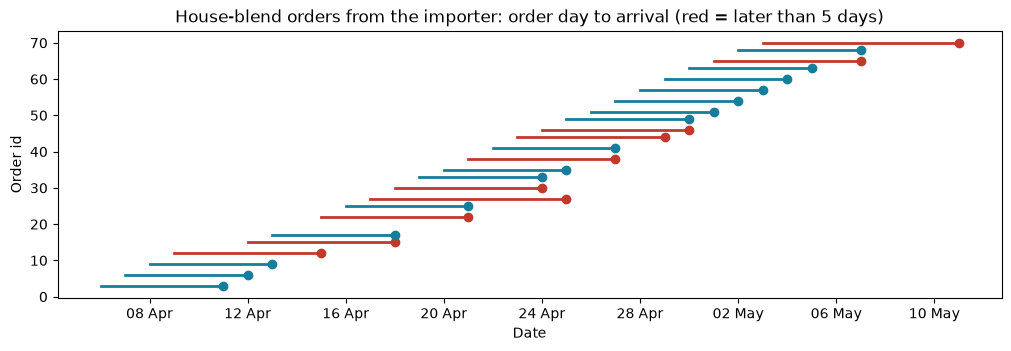

In [19]:
fig, ax = plt.subplots(figsize=(10, 3.4), layout="constrained")
first_weeks = house[house["order_date"] < origin + pd.Timedelta(days=29)]
for _, row in first_weeks.iterrows():
    late = row["lead_time"] > 5
    ax.plot([row["order_date"], row["due_date"]], [row["order_id"]] * 2,
            color="#c0392b" if late else "#167d9a", linewidth=2)
    ax.plot(row["due_date"], row["order_id"], "o", color="#c0392b" if late else "#167d9a")
ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set(title="House-blend orders from the importer: order day to arrival (red = later than 5 days)",
       xlabel="Date", ylabel="Order id")
plt.show()

## 7. Dual sourcing, partial deliveries and a custom rule

Now the buyer uses both suppliers. Two changes:

- The importer ships large orders in two parts: 70% on arrival and 30% two days later (`partial_deliveries`).
- `SupplierShares` sends 30% of every order to the roaster and 70% to the importer. Decaf sells slowly, so it is always bought from the roaster (`by_sku`).

The longest possible delivery is 8 + 2 = 10 days, so this model needs a state with room for at least ten days on order.

In [20]:
importer_split = Supplier("importer", lead_time=importer_lead,
                             partial_deliveries=[(0, 0.7), (2, 0.3)])
roaster = Supplier("roaster", lead_time=1)
dual = SupplyModel(
    [roaster, importer_split],
    allocation=SupplierShares({"roaster": 0.3, "importer": 0.7},
                                 by_sku={"decaf": {"roaster": 1.0}}),
    random_seed=11,
)
print("longest delivery offset:", dual.max_delivery_offset)

max_lead_time = 10  # opening_state() reads this value
wide_state = opening_state().with_open_orders(sunday_orders)  # same Sunday orders, more room
wide_state.open_orders()

longest delivery offset: 10


,order_id,unique_id,supplier_id,source,order_period,ordered_quantity,remaining_quantity,due_period,final_due_period
0,0,house_blend,roaster,opening,0.0,6.0,6.0,1,1
1,1,espresso,roaster,opening,0.0,4.0,4.0,1,1
2,2,decaf,roaster,opening,0.0,1.0,1.0,1,1


With two suppliers, what lead time should the policy plan with? We declare a simple rule: plan with 6 days, the importer's typical arrival plus one day of margin, because most volume comes from the importer. It is a declared assumption to test, not an optimum.

In [21]:
dual_run = run(order_up_to(6), wide_state, supply=dual)
dual_events = dual_run.to_event_frame()
validate_event_frame(dual_events)
print(check_orders_match_events(dual_run))
dual_orders = dual_run.to_order_frame().query("source == 'placed'")
dual_orders[["order_id", "unique_id", "supplier_id", "order_date", "due_date",
             "ordered_quantity", "delivery_quantity"]].head(8)

/home/filtheo/stockcast/src/stockcast/core/simulation_engine.py:2139: UserWarning: supplier deliveries arrive at times other than the policy's lead_time (6 periods). The policy's targets were set for that fixed lead time and are not adjusted, so its protection window does not describe this supply. Results are valid for this assumption; see 'Lead-time assumption' in the suppliers-and-open-orders guide.
  self._warn_supply_timing()


order frame matches the event ledger


,order_id,unique_id,supplier_id,order_date,due_date,ordered_quantity,delivery_quantity
3,3,house_blend,roaster,2026-04-06,2026-04-07,9.9,9.90
4,4,house_blend,importer,2026-04-06,2026-04-11,23.1,16.17
5,4,house_blend,importer,2026-04-06,2026-04-13,23.1,6.93
6,5,espresso,roaster,2026-04-06,2026-04-07,7.2,7.20
7,6,espresso,importer,2026-04-06,2026-04-14,16.8,11.76
8,6,espresso,importer,2026-04-06,2026-04-16,16.8,5.04
9,7,decaf,roaster,2026-04-06,2026-04-07,8.0,8.00
10,8,house_blend,roaster,2026-04-07,2026-04-08,2.1,2.10


In the ledger, `order_quantity` is still the accepted total for each SKU and day, the quantity the policy asked for. `sku_order_line_count` now counts supplier lines: an order split between two suppliers counts as two lines. A partial delivery is still one line.

In [22]:
dual_events.loc[dual_events["order_quantity"] > 0,
                ["date", "unique_id", "order_quantity", "sku_order_line_count", "received_units"]].head(6)

,date,unique_id,order_quantity,sku_order_line_count,received_units
0,2026-04-06,house_blend,33.0,2,6.0
1,2026-04-06,espresso,24.0,2,4.0
2,2026-04-06,decaf,8.0,1,1.0
3,2026-04-07,house_blend,7.0,2,9.9
4,2026-04-07,espresso,8.0,2,7.2
5,2026-04-07,decaf,2.0,1,8.0


### A custom allocation rule: expedite when stock is low

A fixed split ignores the situation on the day. A custom `SupplierAllocation` can use the state the policy saw, together with its open orders. Our rule: if a blend's shelf stock is below 1.5 days of mean demand, buy **everything** from the roaster (it arrives tomorrow); otherwise buy everything from the importer.

The allocation must split each SKU's full accepted quantity. The engine validates the result, and the settings returned by `get_config()` go into the run manifest.

In [23]:
class ExpediteWhenLow(SupplierAllocation):
    # Send an order to the fast supplier when on-hand stock is below a cover threshold.

    def __init__(self, cover_days):
        self.cover_days = cover_days

    def allocate(self, orders, context):
        on_hand = context.inventory.set_index(context.sku_column)["on_hand"]
        low = [on_hand[sku] < self.cover_days * rate[sku] for sku in orders[context.sku_column]]
        return pd.DataFrame({
            context.sku_column: orders[context.sku_column].to_numpy(),
            "supplier_id": ["roaster" if is_low else "importer" for is_low in low],
            "order_quantity": orders["order_quantity"].to_numpy(),
        })

    def get_config(self):
        return {"cover_days": self.cover_days}


expedite = SupplyModel([roaster, importer_split], allocation=ExpediteWhenLow(1.5), random_seed=11)
expedite_run = run(order_up_to(6), wide_state, supply=expedite)
validate_event_frame(expedite_run.to_event_frame())
print(check_orders_match_events(expedite_run))
expedite_run.to_order_frame().query("source == 'placed'").groupby("supplier_id")["order_id"].nunique()

/home/filtheo/stockcast/src/stockcast/core/simulation_engine.py:2139: UserWarning: supplier deliveries arrive at times other than the policy's lead_time (6 periods). The policy's targets were set for that fixed lead time and are not adjusted, so its protection window does not describe this supply. Results are valid for this assumption; see 'Lead-time assumption' in the suppliers-and-open-orders guide.
  self._warn_supply_timing()


order frame matches the event ledger


supplier_id
importer    141
roaster      20
Name: order_id, dtype: int64

## 8. Compare the options

All runs share the same demand. Runs that use the importer share the same lead-time draws (seed 11). The event ledger gives service and stock; the order frame gives purchases **per supplier**. Built-in metrics do not include supplier prices, so we compute purchase cost from the order frame with the declared prices. We count what was *ordered* during the scored weeks, whether or not it has arrived yet.

In [24]:
scored_days = set(demand.loc[demand["period"].between(warmup, warmup + scoring - 1), "date"])


def summarize(result):
    events = result.to_event_frame(window="scoring")
    orders = result.to_order_frame()
    bought = orders[(orders["source"] == "placed") & orders["order_date"].isin(scored_days)]
    # Without a supply model, orders have no supplier id: they are the roaster's in step 1.
    supplier = bought["supplier_id"].fillna("roaster")
    purchase = (bought["delivery_quantity"] * supplier.map(price)).sum()
    holding = holding_cost * events["ending_on_hand"].sum()
    return {
        "fill_rate": fill_rate(events),
        "lost_kg": events["lost_sales_units"].sum(),
        "avg_on_hand_kg": avg_on_hand(events),
        "kg_from_importer": bought.loc[supplier == "importer", "delivery_quantity"].sum(),
        "purchase_eur": purchase,
        "holding_eur": holding,
    }


scenarios = {
    "1. roaster only (per-SKU API)": roaster_only,
    "3. roaster only (new API)": roaster_new_api,
    "5. importer, fixed 5 days": importer_5,
    "6. importer, random, plan L=6": planning["plan L=6"],
    "7a. dual sourcing, 30/70": dual_run,
    "7b. dual, expedite when low": expedite_run,
}
comparison = pd.DataFrame({name: summarize(result) for name, result in scenarios.items()}).T
comparison.round({"fill_rate": 3, "lost_kg": 1, "avg_on_hand_kg": 1, "kg_from_importer": 1,
                  "purchase_eur": 0, "holding_eur": 0})

,fill_rate,lost_kg,avg_on_hand_kg,kg_from_importer,purchase_eur,holding_eur
1. roaster only (per-SKU API),0.966,22.0,4.5,0.0,8806.0,30.0
3. roaster only (new API),0.966,22.0,4.5,0.0,8806.0,30.0
"5. importer, fixed 5 days",0.980,13.0,6.8,639.0,6070.0,46.0
"6. importer, random, plan L=6",0.980,13.0,9.6,639.0,6070.0,64.0
"7a. dual sourcing, 30/70",0.991,5.9,12.9,412.5,7107.0,87.0
"7b. dual, expedite when low",0.975,16.0,8.9,569.0,6316.0,60.0


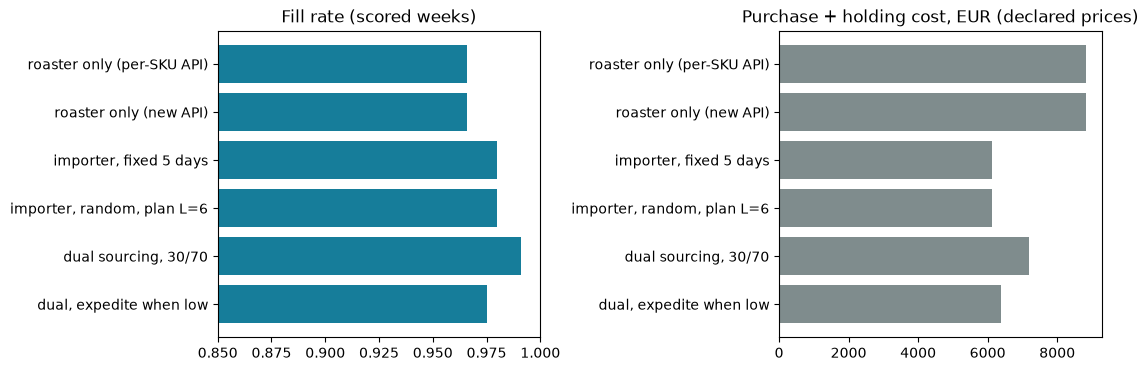

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), layout="constrained")
labels = [name.split(". ", 1)[1] for name in comparison.index]
axes[0].barh(labels, comparison["fill_rate"], color="#167d9a")
axes[0].set(xlim=(0.85, 1.0), title="Fill rate (scored weeks)")
axes[1].barh(labels, comparison["purchase_eur"] + comparison["holding_eur"], color="#7f8c8d")
axes[1].set(title="Purchase + holding cost, EUR (declared prices)")
for ax in axes:
    ax.invert_yaxis()
plt.show()

How to read this, and what it does **not** show:

- Rows 1 and 3 are the same model written in the two APIs, so their numbers are identical.
- Rows 5 and 6 lose the same total by coincidence: the losses fall on different days and blends. An order-up-to policy buys back what was sold, so the purchased kilograms also match. Their stock levels differ.
- The importer is cheaper per kilogram but needs a higher inventory position. Its random lead times cost service unless the plan allows for late arrivals.
- Dual sourcing and the expedite rule trade purchase price against stock and lost sales. Which option is best depends on the declared prices and rates, and on the value of a lost sale, which we did not price. Ten weeks of one artificial demand path is an illustration, not a general ranking.

## Summary

- **Nothing changes by default.** `in_transit`, `OrderDecision` and `supply=None` behave exactly as before.
- **Every per-SKU concept has an order-level form:** `open_orders()` and `with_open_orders(...)` on the state, `OrderLines` with `place_order_lines` in manual loops, `SupplyModel` with `Supplier` in engine runs, and `to_order_frame()` for results. A one-supplier `SupplyModel` with the policy's lead time reproduces the default run exactly.
- **Suppliers** can have fixed or seeded random lead times and partial deliveries. Allocation is either `SupplierShares` or your own `SupplierAllocation`, which sees the state and its open orders.
- **Accounting is unchanged.** The event ledger keeps its identities, and the order frame reconciles with it.

See the guide *Open orders and suppliers* for the full contract and the current scope. [Notebook 05f](05f_unreliable_supplier.ipynb) continues with an unreliable supplier: late and short deliveries found out on the due day (`DeliveryOutcome`), supplier capacity built from an ordering constraint or an allocation, and a backup supplier chosen by the policy. Multi-echelon networks are not modelled.